# 04. Tiny GPT from Scratch

**Topics covered:** Full GPT Architecture · Positional Encoding · Causal Language Modeling

This notebook assembles everything from the previous three notebooks into a complete **decoder-only Transformer** (GPT-style) that can be trained on a tiny character-level dataset.

We will:
1. Add **token embeddings** and **positional encodings**
2. Stack Transformer blocks into a full **GPT model**
3. Implement the **causal language modeling** objective
4. Train a tiny model on a small text corpus
5. Generate text with the trained model

## 1. Setup & Imports

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


## 2. Positional Encoding

Transformers have no inherent notion of order. We inject position information via **positional encodings**.

### Absolute sinusoidal (original Transformer)

$$
PE_{(pos, 2i)}   = \sin\bigl(pos / 10000^{2i/d_{model}}\bigr)
$$
$$
PE_{(pos, 2i+1)} = \cos\bigl(pos / 10000^{2i/d_{model}}\bigr)
$$

### Learned absolute embeddings (GPT-2 style)

Most modern decoder-only models simply use a learned embedding table of shape `(max_seq_len, d_model)` that is added to the token embeddings.

We implement both and use the **learned** version for our Tiny GPT.

In [2]:
class SinusoidalPositionalEncoding(nn.Module):
    """Fixed sinusoidal positional encodings (Vaswani et al.)."""
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class LearnedPositionalEncoding(nn.Module):
    """Learned absolute positional embeddings (GPT-2 style)."""
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device)
        x = x + self.pos_emb(positions)
        return self.dropout(x)

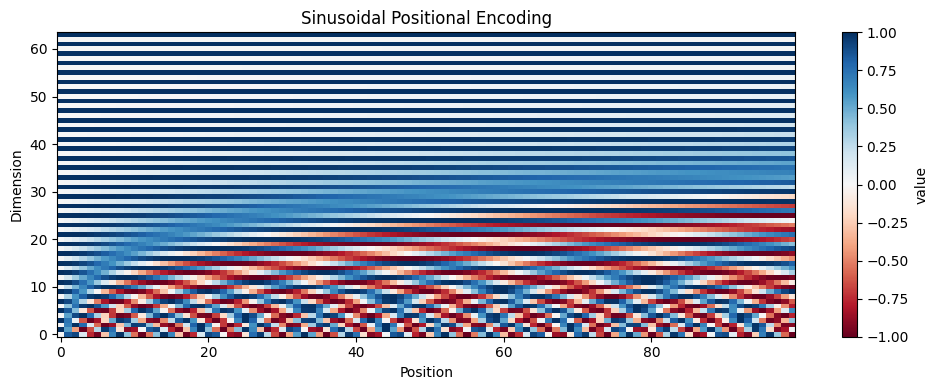

In [3]:
# Visualise sinusoidal encodings
pe = SinusoidalPositionalEncoding(d_model=64, max_len=100, dropout=0.0)
dummy = torch.zeros(1, 100, 64)
enc = pe(dummy).squeeze(0).detach().numpy()

plt.figure(figsize=(10, 4))
plt.imshow(enc.T, aspect="auto", cmap="RdBu", origin="lower")
plt.colorbar(label="value")
plt.xlabel("Position")
plt.ylabel("Dimension")
plt.title("Sinusoidal Positional Encoding")
plt.tight_layout()
plt.show()

## 3. Building Blocks (from previous notebooks)

We reuse compact versions of Multi-Head Attention, Feed-Forward and the Transformer Block.

In [4]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        if mask.dtype == torch.bool:
            scores = scores.masked_fill(~mask, float("-inf"))
        else:
            scores = scores + mask
    attn = F.softmax(scores, dim=-1)
    return torch.matmul(attn, V)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, _ = x.size()
        Q = self.W_Q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        if mask is not None and mask.dim() == 2:
            mask = mask.unsqueeze(0).unsqueeze(0)
        out = scaled_dot_product_attention(Q, K, V, mask)
        out = out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.dropout(self.W_O(out))


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """Pre-LN Transformer block."""
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)

    def forward(self, x, mask=None):
        x = x + self.attn(self.ln1(x), mask=mask)
        x = x + self.ffn(self.ln2(x))
        return x

## 4. The Tiny GPT Model

A decoder-only GPT consists of:

1. **Token embedding** – maps token IDs → vectors
2. **Positional embedding** – adds position information
3. **Stack of Transformer blocks** – the core computation
4. **Final LayerNorm**
5. **Language-model head** – projects back to vocabulary logits

The causal mask ensures that position $i$ can only attend to positions $\le i$.

In [5]:
class TinyGPT(nn.Module):
    """
    Minimal GPT-style language model.

    Args:
        vocab_size  : size of the vocabulary
        d_model     : embedding / hidden dimension
        n_heads     : number of attention heads
        n_layers    : number of Transformer blocks
        max_seq_len : maximum context length
        dropout     : dropout probability
    """
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 128,
        n_heads: int = 4,
        n_layers: int = 4,
        max_seq_len: int = 128,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.max_seq_len = max_seq_len

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = LearnedPositionalEncoding(d_model, max_seq_len, dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying (common in modern LMs)
        self.token_emb.weight = self.lm_head.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        Args:
            idx     : (batch, seq_len) token indices
            targets : (batch, seq_len) optional target indices for loss

        Returns:
            logits  : (batch, seq_len, vocab_size)
            loss    : scalar (if targets given)
        """
        B, T = idx.size()
        assert T <= self.max_seq_len, f"Sequence length {T} > max_seq_len {self.max_seq_len}"

        # Token + position embeddings
        x = self.token_emb(idx)          # (B, T, d_model)
        x = self.pos_emb(x)

        # Causal mask
        mask = torch.tril(torch.ones(T, T, dtype=torch.bool, device=idx.device))

        # Transformer body
        for block in self.blocks:
            x = block(x, mask=mask)

        x = self.ln_f(x)
        logits = self.lm_head(x)         # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=50, temperature=1.0, top_k=None):
        """
        Autoregressive generation.

        Args:
            idx            : (batch, T) starting tokens
            max_new_tokens : number of tokens to generate
            temperature    : softmax temperature
            top_k          : if set, sample only from top-k logits
        """
        for _ in range(max_new_tokens):
            # Crop to max context length
            idx_cond = idx[:, -self.max_seq_len:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature   # (B, vocab)

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("inf")

            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)  # (B, 1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx

In [6]:
# Quick architecture check
model = TinyGPT(vocab_size=65, d_model=64, n_heads=4, n_layers=2, max_seq_len=64).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TinyGPT(
  (token_emb): Embedding(65, 64)
  (pos_emb): LearnedPositionalEncoding(
    (pos_emb): Embedding(64, 64)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (W_Q): Linear(in_features=64, out_features=64, bias=False)
        (W_K): Linear(in_features=64, out_features=64, bias=False)
        (W_V): Linear(in_features=64, out_features=64, bias=False)
        (W_O): Linear(in_features=64, out_features=64, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=64, bias=True)
          (4): D

## 5. Tiny Character-Level Dataset

We use a short public-domain text (Shakespeare excerpt style) so the notebook runs quickly on CPU/GPU.

In [7]:
# Small public-domain style corpus (character-level)
text = """
To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay, there's the rub:
For in that sleep of death what dreams may come
When we have shuffled off this mortal coil,
Must give us pause—there's the respect
That makes calamity of so long life.
""".strip().lower()

# Build vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join(itos[i] for i in ids)

print(f"Vocab size : {vocab_size}")
print(f"Characters : {''.join(chars)}")
print(f"Text length: {len(text)} characters")
print(f"Encoded sample: {encode(text[:30])}")

Vocab size : 32
Characters : 
 ',-.:;abcdefghiklmnopqrstuvwy—
Text length: 601 characters
Encoded sample: [26, 21, 1, 9, 12, 3, 1, 21, 24, 1, 20, 21, 26, 1, 26, 21, 1, 9, 12, 3, 1, 26, 15, 8, 26, 1, 16, 25, 1, 26]


In [8]:
class CharDataset(Dataset):
    def __init__(self, data, block_size):
        self.data = torch.tensor(encode(data), dtype=torch.long)
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        chunk = self.data[idx : idx + self.block_size + 1]
        x = chunk[:-1]
        y = chunk[1:]
        return x, y


block_size = 64
dataset = CharDataset(text, block_size)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

xb, yb = next(iter(loader))
print("Input batch shape :", xb.shape)
print("Target batch shape:", yb.shape)
print("Decoded input sample:", decode(xb[0].tolist())[:50], "...")

Input batch shape : torch.Size([16, 64])
Target batch shape: torch.Size([16, 64])
Decoded input sample: rtal coil,
must give us pause—there's the respect
 ...


## 6. Training Loop (Causal Language Modeling)

The objective is next-token prediction:

$$
\mathcal{L} = -\sum_t \log p(x_t \mid x_{<t})
$$

In [9]:
# Model hyper-parameters (kept intentionally small for fast runs)
config = dict(
    vocab_size=vocab_size,
    d_model=64,
    n_heads=4,
    n_layers=3,
    max_seq_len=block_size,
    dropout=0.1,
)

model = TinyGPT(**config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 155,456


In [10]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        _, loss = model(xb, targets=yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        _, loss = model(xb, targets=yb)
        total_loss += loss.item()
    return total_loss / len(loader)

In [11]:
# Short training run (increase epochs for better quality)
num_epochs = 30
train_losses = []

for epoch in range(1, num_epochs + 1):
    loss = train_epoch(model, loader, optimizer, device)
    train_losses.append(loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train loss {loss:.4f}")

print("Training finished.")

Epoch   1 | train loss 2.6278
Epoch   5 | train loss 1.1251
Epoch  10 | train loss 0.4260
Epoch  15 | train loss 0.2667
Epoch  20 | train loss 0.2077
Epoch  25 | train loss 0.1688
Epoch  30 | train loss 0.1550
Training finished.


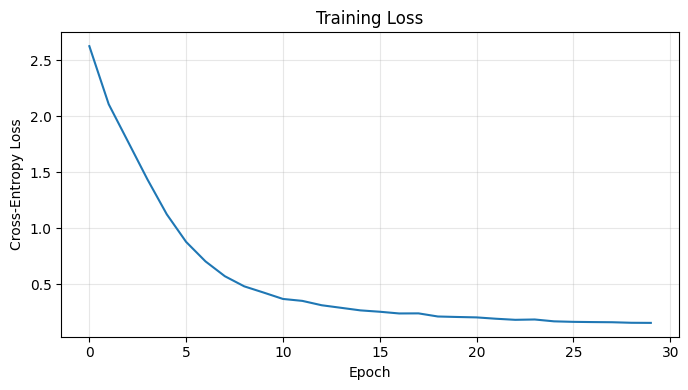

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Text Generation

In [13]:
model.eval()

# Start from a short prompt
prompt = "to be, or not"
start_ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

generated = model.generate(start_ids, max_new_tokens=120, temperature=0.8, top_k=20)
print("Prompt :", prompt)
print("Generated:")
print(decode(generated[0].tolist()))

Prompt : to be, or not
Generated:
to be, or not to be, that is the question:
wher 'tis nobler in the mind to suffer
the slings and arrows of outrageous fortune,
or to 


In [14]:
# A few more samples with different temperatures
for temp in [0.5, 0.9, 1.2]:
    g = model.generate(start_ids, max_new_tokens=80, temperature=temp, top_k=30)
    print(f"\n--- temperature={temp} ---")
    print(decode(g[0].tolist()))


--- temperature=0.5 ---
to be, or not t to be, that is the question:
wher 'tis nobler in the mind to suffer
the sling

--- temperature=0.9 ---
to be, or not t to be, that is the question:
wher 'tis nobler in the mind to suffer
the sling

--- temperature=1.2 ---
to be, or not be, that is the question:
whether 'tis nobler in the mind to suffer
the slings 


## 8. Model Summary & Parameter Breakdown

In [15]:
def count_parameters(model):
    total = 0
    print(f"{'Module':<35} {'Params':>10}")
    print("-" * 47)
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:  # leaf modules
            n = sum(p.numel() for p in module.parameters())
            if n > 0:
                print(f"{name:<35} {n:>10,}")
                total += n
    print("-" * 47)
    print(f"{'Total':<35} {total:>10,}")
    return total

_ = count_parameters(model)

Module                                  Params
-----------------------------------------------
token_emb                                2,048
pos_emb.pos_emb                          4,096
blocks.0.ln1                               128
blocks.0.attn.W_Q                        4,096
blocks.0.attn.W_K                        4,096
blocks.0.attn.W_V                        4,096
blocks.0.attn.W_O                        4,096
blocks.0.ln2                               128
blocks.0.ffn.net.0                      16,640
blocks.0.ffn.net.3                      16,448
blocks.1.ln1                               128
blocks.1.attn.W_Q                        4,096
blocks.1.attn.W_K                        4,096
blocks.1.attn.W_V                        4,096
blocks.1.attn.W_O                        4,096
blocks.1.ln2                               128
blocks.1.ffn.net.0                      16,640
blocks.1.ffn.net.3                      16,448
blocks.2.ln1                               128
blocks.2.att

## 9. Summary

| Component | Role |
|-----------|------|
| **Token Embedding** | Maps discrete tokens → continuous vectors |
| **Positional Encoding** | Injects order (learned absolute embeddings in GPT-style models) |
| **Transformer Blocks** | Stack of Pre-LN attention + FFN with residuals |
| **Final LayerNorm** | Stabilises the residual stream before the head |
| **LM Head** | Projects hidden states back to vocabulary logits |
| **Causal Mask** | Enforces left-to-right (autoregressive) attention |
| **Weight Tying** | Shares token embedding and LM-head weights |

### Full forward pass

```
token ids
   ↓
Token Embedding + Positional Embedding
   ↓
× N  Transformer Blocks  (causal attention + FFN)
   ↓
Final LayerNorm
   ↓
LM Head → logits over vocabulary
   ↓
Cross-Entropy loss (next-token prediction)
```

### Key take-aways

- A GPT is just a stack of the Transformer blocks you built in notebook 03, plus embeddings and a language-model head.
- Causal masking turns the bidirectional attention into an autoregressive language model.
- Even a tiny model (~tens of thousands of parameters) can learn local patterns of a small character-level corpus.
- Scaling depth, width, data and compute is what turns this architecture into modern LLMs.

---

**You have now completed the `01_attention_transformers` series.**

Next folder in the curriculum: **`02_huggingface_basics`**  
→ `01_loading_models_and_tokenizers.ipynb`